In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
# from matplotlib.colors import ListedColormap5
import ast
import numpy as np
import os
import subprocess
import time
import plotly.express as px

%matplotlib inline

In [86]:
# Constants
MIN_5 = 320
MIN_10 = 620
MIN_15 = 1000
MIN_30 = 1820
MIN_60 = 3620
MIN_120 = 7220

COLLOR_PALLET = {
            'Other human': '#2986cc', # BLUE
            'Electro-mechanical': '#cc0000', # RED
            'Voice': '#6aa84f', #  green 6aa84f
            'Motorised transport': '#ffa500', # orange
            'Geonature': '#8e7cc3', # PURPLE
            'Animal': '#9b5f00', # BROWN
            'Music': '#d172a4', # PINK
            'Background': '#000000', # BLACK
            'Other Sounds': '#c9d631', # yellow
            'Social/communal': '#d8cbf8', # Light purple
            'Human movement': '#40b674', # light green 40b674
        }

def extract_location(file_path):
    file_name = os.path.basename(file_path)
    # print(f"File name: {file_name}")
    # Split the file name by the underscore
    file_name = file_name.split("_")[2]
    # print(f"File name after split: {file_name}")
    return file_name

def remove_label(classes_list, label):
    return [x for x in classes_list if x != label]

def change_label(classes_list, label, new_label):
    return [new_label if x == label else x for x in classes_list]

def first_element(classes_list):
    return [classes_list[0]] if classes_list else []

def interval_printing(average_interval):
    if average_interval > 0 and average_interval < MIN_5:
        print(f"The average interval between each audio file is 5 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_5 and average_interval < MIN_10:
        print(f"The average interval between each audio file is 10 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_10 and average_interval < MIN_15:
        print(f"The average interval between each audio file is 15 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_15 and average_interval < MIN_30:
        print(f"The average interval between each audio file is 30 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_30 and average_interval < MIN_60:
        print(f"The average interval between each audio file is 60 minutes ({round(average_interval)} seconds), which are {round(average_interval/60)} minutes)")
    elif average_interval > MIN_60 and average_interval < MIN_120:
        print(f"The average interval between each audio file is 120 minutes ({round(average_interval)} seconds, which are {round(average_interval/60)} minutes)")

def insert_dates(df):
    df["year"] = df.index.year
    df["month"] = df.index.month
    df["day"] = df.index.day
    df["hour"] = df.index.hour
    df["minute"] = df.index.minute
    df["second"] = df.index.second
    df["weekday"] = df.index.day_name()

    weekday_translation = {
        "Monday": " Lunes",
        "Tuesday": " Martes",
        "Wednesday": " Miércoles",
        "Thursday": " Jueves",
        "Friday": " Viernes",
        "Saturday": " Sábado",
        "Sunday": " Domingo"
    }
    df["weekday"] = df["weekday"].replace(weekday_translation)
    df["weekday"] = df["weekday"].astype(str)
    df["day"] = df["day"].astype(str).str.zfill(2)
    df["fullday"] = df["day"] + df["weekday"]

    return df

def output_dir(path: str):
    # get the abs path and remove the last element
    path = os.path.abspath(path).split("\\")[:-2]
    path = "/".join(path)
    
    visualization_dir = path + "/Visualizations"
    os.makedirs(visualization_dir, exist_ok=True)
    
    return visualization_dir

# get the last git tag version
def list_git_tags():
    try:
        tags = tags = subprocess.check_output(["git", "tag"]).strip().decode()
        return tags.split('\n')
    except subprocess.CalledProcessError:
        return None
    
def select_tag(tags):
    for i, tag in enumerate(tags):
        print(f"{i}: {tag}")
    choice = int(input("Select the tag to use: "))
    tag_selected = tags[choice]
    # replace "." with "_" to be able to use it as a file name
    tag_selected = tag_selected.replace(".", "_")
        
    return tag_selected

def get_stable_version():
    tags = list_git_tags()
    # get the latest stable version
    tag_selected = tags[-1]
    print(f"Latest stable version: {tag_selected}")
    # replace "." with "_" to be able to use it as a file name
    tag_selected = tag_selected.replace(".", "_")
    
    print(f"Latest stable version: {tag_selected}")
    
    return tag_selected

print(get_stable_version())
stable_version = get_stable_version()

Latest stable version: v1.0
Latest stable version: v1_0
v1_0
Latest stable version: v1.0
Latest stable version: v1_0


In [87]:
csv_pred_path = input("Enter the path to the csv file: ")

# clean the csv_pred_path from " and "
csv_pred_path = csv_pred_path.replace('"', '')

# make visualization directory
visualization_dir = output_dir(csv_pred_path)

# get the csv
df = pd.read_csv(csv_pred_path, converters={'classes_custom': eval, 'classes_original': eval})

# get the location
title = extract_location(csv_pred_path)

df

,files,datetime,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original
0,20231211_140420.WAV,2023-12-11 14:04:20,"[Motorised transport, Background, Other Sounds]",[0.04712101 0.04712101 0.04047813],0.134720,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.58924985, 0.19037996, 0.13706653]",0.916696
1,20231211_141925.WAV,2023-12-11 14:19:25,"[Motorised transport, Background, Other Sounds]",[0.04974215 0.04974215 0.04835489],0.147839,"[Vehicle, Aircraft, Rail transport]","[0.5450827, 0.110651635, 0.08248865]",0.738223
2,20231211_143430.WAV,2023-12-11 14:34:30,"[Motorised transport, Music, Background]",[0.04876277 0.04876277 0.04278513],0.140311,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.59034604, 0.18713339, 0.14209369]",0.919573
3,20231211_144935.WAV,2023-12-11 14:49:35,"[Motorised transport, Music, Social/communal]",[0.12977923 0.12977923 0.06399534],0.323554,"[Vehicle, Rail transport, Train]","[0.43870002, 0.10387543, 0.100696936]",0.643272
4,20231211_150440.WAV,2023-12-11 15:04:40,"[Motorised transport, Other Sounds, Background]",[0.05102908 0.05102908 0.04548863],0.147547,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.48237646, 0.18065579, 0.12274324]",0.785775
...,...,...,...,...,...,...,...,...
769,20231219_200620.WAV,2023-12-19 20:06:20,"[Motorised transport, Background, Other Sounds]",[0.05270417 0.05270417 0.05156299],0.156971,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.44681683, 0.21643335, 0.18172546]",0.844976
770,20231219_203630.WAV,2023-12-19 20:36:30,"[Motorised transport, Background, Electro-mech...",[0.05028025 0.05028025 0.04867538],0.149236,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.46663454, 0.21194497, 0.1803219]",0.858901
771,20231219_210640.WAV,2023-12-19 21:06:40,"[Motorised transport, Other Sounds, Electro-me...",[0.05549388 0.05549388 0.05487871],0.165866,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.4598495, 0.19513136, 0.1635742]",0.818555
772,20231219_232225.WAV,2023-12-19 23:22:25,"[Motorised transport, Other Sounds, Electro-me...",[0.08302794 0.08302794 0.07354094],0.239597,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.42526704, 0.14884457, 0.121698745]",0.695810


In [88]:
print("We are working with {} processing results".format(len(df)))
print(f"We are working within the time range from [ {df['datetime'].min()} ] to [ {df['datetime'].max()} ]")

df['datetime'] = pd.to_datetime(df['datetime'])
time_difference_seconds = df['datetime'].diff().dt.total_seconds()
average_interval = time_difference_seconds.mean()
interval_printing(average_interval)

We are working with 774 processing results
We are working within the time range from [ 2023-12-11 14:04:20 ] to [ 2023-12-19 23:52:35 ]
The average interval between each audio file is 15 minutes (940 seconds, which are 16 minutes)


In [89]:
# convert string to list
# df['classes_custom'] = df['classes_custom'].apply(ast.literal_eval)

print(f"Type of the column: \t\t {type(df['classes_custom'])}")
print(f"Type of the first element: \t\t {type(df['classes_custom'][0])}")

# remove labels
# df['classes_custom'] = df['classes_custom'].apply(lambda x: remove_label(x, 'Nature'))
# df['classes_custom'] = df['classes_custom'].apply(lambda x: remove_label(x, 'Animal'))

# change labels
# df['classes_custom'] = df['classes_custom'].apply(lambda x: change_label(x, 'Animal', 'Other Sounds'))
# df['classes_custom'] = df['classes_custom'].apply(lambda x: change_label(x, 'Other human', 'Other Sounds'))

df['classes_custom']

Type of the column: 		 <class 'pandas.core.series.Series'>
Type of the first element: 		 <class 'list'>


0        [Motorised transport, Background, Other Sounds]
1        [Motorised transport, Background, Other Sounds]
2               [Motorised transport, Music, Background]
3          [Motorised transport, Music, Social/communal]
4        [Motorised transport, Other Sounds, Background]
                             ...                        
769      [Motorised transport, Background, Other Sounds]
770    [Motorised transport, Background, Electro-mech...
771    [Motorised transport, Other Sounds, Electro-me...
772    [Motorised transport, Other Sounds, Electro-me...
773    [Motorised transport, Other Sounds, Electro-me...
Name: classes_custom, Length: 774, dtype: object

In [90]:
# print("Nature" in df['classes_custom'])
# print("Voice" in df['classes_custom'])

In [91]:
df

,files,datetime,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original
0,20231211_140420.WAV,2023-12-11 14:04:20,"[Motorised transport, Background, Other Sounds]",[0.04712101 0.04712101 0.04047813],0.134720,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.58924985, 0.19037996, 0.13706653]",0.916696
1,20231211_141925.WAV,2023-12-11 14:19:25,"[Motorised transport, Background, Other Sounds]",[0.04974215 0.04974215 0.04835489],0.147839,"[Vehicle, Aircraft, Rail transport]","[0.5450827, 0.110651635, 0.08248865]",0.738223
2,20231211_143430.WAV,2023-12-11 14:34:30,"[Motorised transport, Music, Background]",[0.04876277 0.04876277 0.04278513],0.140311,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.59034604, 0.18713339, 0.14209369]",0.919573
3,20231211_144935.WAV,2023-12-11 14:49:35,"[Motorised transport, Music, Social/communal]",[0.12977923 0.12977923 0.06399534],0.323554,"[Vehicle, Rail transport, Train]","[0.43870002, 0.10387543, 0.100696936]",0.643272
4,20231211_150440.WAV,2023-12-11 15:04:40,"[Motorised transport, Other Sounds, Background]",[0.05102908 0.05102908 0.04548863],0.147547,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.48237646, 0.18065579, 0.12274324]",0.785775
...,...,...,...,...,...,...,...,...
769,20231219_200620.WAV,2023-12-19 20:06:20,"[Motorised transport, Background, Other Sounds]",[0.05270417 0.05270417 0.05156299],0.156971,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.44681683, 0.21643335, 0.18172546]",0.844976
770,20231219_203630.WAV,2023-12-19 20:36:30,"[Motorised transport, Background, Electro-mech...",[0.05028025 0.05028025 0.04867538],0.149236,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.46663454, 0.21194497, 0.1803219]",0.858901
771,20231219_210640.WAV,2023-12-19 21:06:40,"[Motorised transport, Other Sounds, Electro-me...",[0.05549388 0.05549388 0.05487871],0.165866,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.4598495, 0.19513136, 0.1635742]",0.818555
772,20231219_232225.WAV,2023-12-19 23:22:25,"[Motorised transport, Other Sounds, Electro-me...",[0.08302794 0.08302794 0.07354094],0.239597,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.42526704, 0.14884457, 0.121698745]",0.695810


In [92]:
# df['classes_custom'] = df['classes_custom'].apply(first_element)
# df['classes_custom']

# df

In [93]:
print(f"These are the class count:\n\n{df['classes_custom'].value_counts()}")

print(f"\nThese are the class summed: \t\t {df['classes_custom'].value_counts().sum()}")
print(f"This is the lenght of the dataframe \t {len(df)}")

These are the class count:

[Motorised transport, Other Sounds, Background]               315
[Motorised transport, Background, Other Sounds]               131
[Motorised transport, Electro-mechanical, Background]          56
[Motorised transport, Other Sounds, Electro-mechanical]        50
[Motorised transport, Background, Electro-mechanical]          39
[Motorised transport, Other Sounds, Geonature]                 26
[Motorised transport, Geonature, Background]                   25
[Motorised transport, Social/communal, Other Sounds]           20
[Motorised transport, Electro-mechanical, Other Sounds]        19
[Motorised transport, Geonature, Other Sounds]                 14
[Motorised transport, Social/communal, Background]             13
[Motorised transport, Background, Animal]                       8
[Motorised transport, Animal, Background]                       8
[Motorised transport, Other Sounds, Social/communal]            6
[Motorised transport, Other Sounds, Animal]     

In [94]:
df['single_class'] = df['classes_custom'].apply(lambda x: x[0] if x else None)
df.set_index("datetime", inplace=True)
df = insert_dates(df)

In [95]:
df

,files,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original,single_class,year,month,day,hour,minute,second,weekday,fullday
datetime,,,,,,,,,,,,,,,,
2023-12-11 14:04:20,20231211_140420.WAV,"[Motorised transport, Background, Other Sounds]",[0.04712101 0.04712101 0.04047813],0.134720,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.58924985, 0.19037996, 0.13706653]",0.916696,Motorised transport,2023,12,11,14,4,20,Lunes,11 Lunes
2023-12-11 14:19:25,20231211_141925.WAV,"[Motorised transport, Background, Other Sounds]",[0.04974215 0.04974215 0.04835489],0.147839,"[Vehicle, Aircraft, Rail transport]","[0.5450827, 0.110651635, 0.08248865]",0.738223,Motorised transport,2023,12,11,14,19,25,Lunes,11 Lunes
2023-12-11 14:34:30,20231211_143430.WAV,"[Motorised transport, Music, Background]",[0.04876277 0.04876277 0.04278513],0.140311,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.59034604, 0.18713339, 0.14209369]",0.919573,Motorised transport,2023,12,11,14,34,30,Lunes,11 Lunes
2023-12-11 14:49:35,20231211_144935.WAV,"[Motorised transport, Music, Social/communal]",[0.12977923 0.12977923 0.06399534],0.323554,"[Vehicle, Rail transport, Train]","[0.43870002, 0.10387543, 0.100696936]",0.643272,Motorised transport,2023,12,11,14,49,35,Lunes,11 Lunes
2023-12-11 15:04:40,20231211_150440.WAV,"[Motorised transport, Other Sounds, Background]",[0.05102908 0.05102908 0.04548863],0.147547,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.48237646, 0.18065579, 0.12274324]",0.785775,Motorised transport,2023,12,11,15,4,40,Lunes,11 Lunes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-19 20:06:20,20231219_200620.WAV,"[Motorised transport, Background, Other Sounds]",[0.05270417 0.05270417 0.05156299],0.156971,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.44681683, 0.21643335, 0.18172546]",0.844976,Motorised transport,2023,12,19,20,6,20,Martes,19 Martes
2023-12-19 20:36:30,20231219_203630.WAV,"[Motorised transport, Background, Electro-mech...",[0.05028025 0.05028025 0.04867538],0.149236,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.46663454, 0.21194497, 0.1803219]",0.858901,Motorised transport,2023,12,19,20,36,30,Martes,19 Martes
2023-12-19 21:06:40,20231219_210640.WAV,"[Motorised transport, Other Sounds, Electro-me...",[0.05549388 0.05549388 0.05487871],0.165866,"[Vehicle, Aircraft, Fixed-wing aircraft, airpl...","[0.4598495, 0.19513136, 0.1635742]",0.818555,Motorised transport,2023,12,19,21,6,40,Martes,19 Martes


Saved image at //192.168.205.117/AAC_Server/PUERTOS/NOISEPORT/20231211_SANTUR/5-Resultados/P1_CONTENEDORES/URBAN_Model/Visualizations/P1_predictions_map_v1_0.png


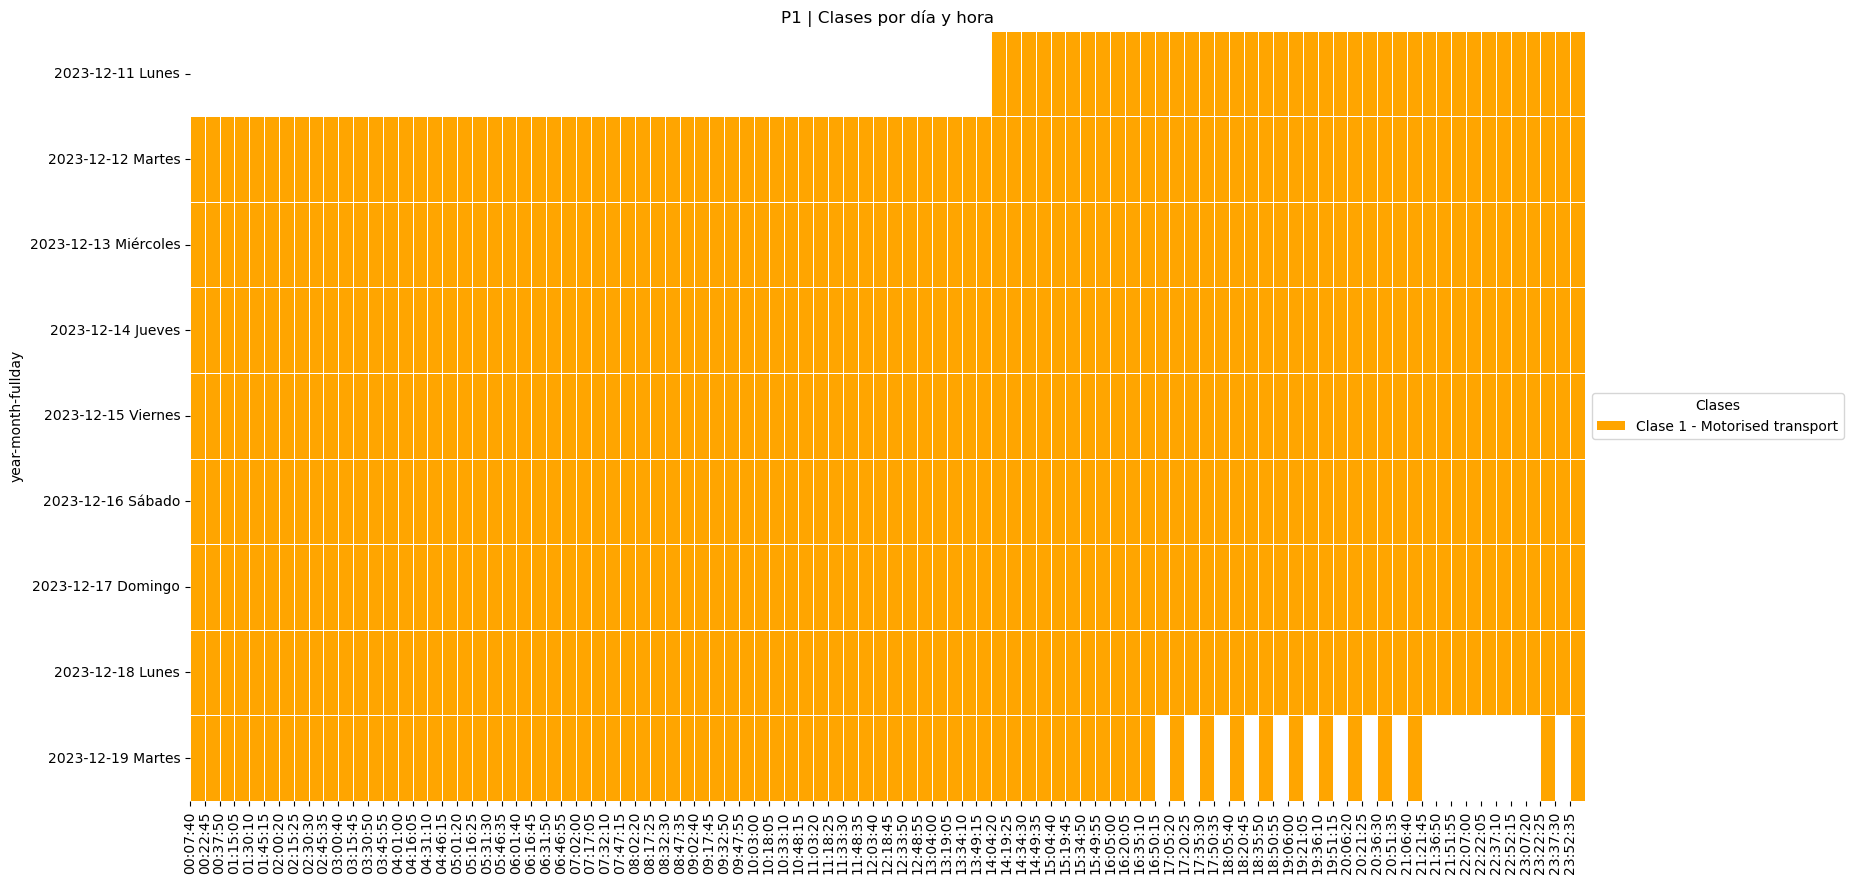

In [96]:
df = df.sort_values(by=["year", "month", "fullday"])

# map class to number
class_to_num = {class_name: index+1 for index, class_name in enumerate(df['single_class'].unique())}
df['class_num'] = df['single_class'].map(class_to_num)

# inverting the dictionary to get the name of the class for the legend
name_class = {v: k for k, v in class_to_num.items()}

# mapping from classes numbers to colors
num_to_color = {num: COLLOR_PALLET[class_name] for class_name, num in class_to_num.items()}
cmap = [num_to_color[cls_num] for cls_num in name_class.keys()]

# leggend elements colors
legend_elements = [Patch(facecolor=num_to_color[cls_num], label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num in name_class.keys()]

day_class = pd.pivot_table(data=df, columns=df.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

plt.figure(figsize=(18, 10))

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
    
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

    plt.savefig(f"{visualization_dir}/{title}_predictions_map_{stable_version}.png", bbox_inches='tight')
    print(f"Saved image at {visualization_dir}/{title}_predictions_map_{stable_version}.png")

plt.show()

# Stack Bar Plotting

In [97]:
df_explode = df.explode('classes_original')
df_explode

,files,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original,single_class,year,month,day,hour,minute,second,weekday,fullday,class_num
datetime,,,,,,,,,,,,,,,,,
2023-12-11 14:04:20,20231211_140420.WAV,"[Motorised transport, Background, Other Sounds]",[0.04712101 0.04712101 0.04047813],0.134720,Vehicle,"[0.58924985, 0.19037996, 0.13706653]",0.916696,Motorised transport,2023,12,11,14,4,20,Lunes,11 Lunes,1
2023-12-11 14:04:20,20231211_140420.WAV,"[Motorised transport, Background, Other Sounds]",[0.04712101 0.04712101 0.04047813],0.134720,Aircraft,"[0.58924985, 0.19037996, 0.13706653]",0.916696,Motorised transport,2023,12,11,14,4,20,Lunes,11 Lunes,1
2023-12-11 14:04:20,20231211_140420.WAV,"[Motorised transport, Background, Other Sounds]",[0.04712101 0.04712101 0.04047813],0.134720,"Fixed-wing aircraft, airplane","[0.58924985, 0.19037996, 0.13706653]",0.916696,Motorised transport,2023,12,11,14,4,20,Lunes,11 Lunes,1
2023-12-11 14:19:25,20231211_141925.WAV,"[Motorised transport, Background, Other Sounds]",[0.04974215 0.04974215 0.04835489],0.147839,Vehicle,"[0.5450827, 0.110651635, 0.08248865]",0.738223,Motorised transport,2023,12,11,14,19,25,Lunes,11 Lunes,1
2023-12-11 14:19:25,20231211_141925.WAV,"[Motorised transport, Background, Other Sounds]",[0.04974215 0.04974215 0.04835489],0.147839,Aircraft,"[0.5450827, 0.110651635, 0.08248865]",0.738223,Motorised transport,2023,12,11,14,19,25,Lunes,11 Lunes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-19 23:22:25,20231219_232225.WAV,"[Motorised transport, Other Sounds, Electro-me...",[0.08302794 0.08302794 0.07354094],0.239597,Aircraft,"[0.42526704, 0.14884457, 0.121698745]",0.695810,Motorised transport,2023,12,19,23,22,25,Martes,19 Martes,1
2023-12-19 23:22:25,20231219_232225.WAV,"[Motorised transport, Other Sounds, Electro-me...",[0.08302794 0.08302794 0.07354094],0.239597,"Fixed-wing aircraft, airplane","[0.42526704, 0.14884457, 0.121698745]",0.695810,Motorised transport,2023,12,19,23,22,25,Martes,19 Martes,1
2023-12-19 23:52:35,20231219_235235.WAV,"[Motorised transport, Other Sounds, Electro-me...",[0.11863459 0.11863459 0.09503771],0.332307,Vehicle,"[0.41828883, 0.10554206, 0.08120222]",0.605033,Motorised transport,2023,12,19,23,52,35,Martes,19 Martes,1


In [98]:
df_explode['display_name'] = df_explode['classes_original']

# read ontology union file
union = pd.read_csv(r"C:\Users\GIS2\Documents\santi\GitHub\AAC\AI_Model\Urban_Model\taxonomy_mapping\yamnet_class_AAC_v1_0.csv",sep=';')

# merge classes with ontology
df_explode = df_explode.merge(
    union,
    how='left',
    on='display_name'
    )

df_explode

,files,classes_custom,probabilities_custom,sum_probs_custom,classes_original,probabilities_original,sum_probs_original,single_class,year,month,...,mid,iso_taxonomy,Brown_Level_1,Brown_Level_2,Brown_Level_3,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,20231211_140420.WAV,"[Motorised transport, Background, Other Sounds]",[0.04712101 0.04712101 0.04047813],0.134720,Vehicle,"[0.58924985, 0.19037996, 0.13706653]",0.916696,Motorised transport,2023,12,...,/m/07yv9,Roadway traffic,NaN,Motorised transport,roadway traffic,NaN,NaN,NaN,NaN,NaN
1,20231211_140420.WAV,"[Motorised transport, Background, Other Sounds]",[0.04712101 0.04712101 0.04047813],0.134720,Aircraft,"[0.58924985, 0.19037996, 0.13706653]",0.916696,Motorised transport,2023,12,...,/m/0k5j,Air traffic,NaN,Motorised transport,air traffic,NaN,NaN,NaN,NaN,NaN
2,20231211_140420.WAV,"[Motorised transport, Background, Other Sounds]",[0.04712101 0.04712101 0.04047813],0.134720,"Fixed-wing aircraft, airplane","[0.58924985, 0.19037996, 0.13706653]",0.916696,Motorised transport,2023,12,...,/m/0cmf2,Air traffic,NaN,Motorised transport,air traffic,NaN,NaN,NaN,NaN,NaN
3,20231211_141925.WAV,"[Motorised transport, Background, Other Sounds]",[0.04974215 0.04974215 0.04835489],0.147839,Vehicle,"[0.5450827, 0.110651635, 0.08248865]",0.738223,Motorised transport,2023,12,...,/m/07yv9,Roadway traffic,NaN,Motorised transport,roadway traffic,NaN,NaN,NaN,NaN,NaN
4,20231211_141925.WAV,"[Motorised transport, Background, Other Sounds]",[0.04974215 0.04974215 0.04835489],0.147839,Aircraft,"[0.5450827, 0.110651635, 0.08248865]",0.738223,Motorised transport,2023,12,...,/m/0k5j,Air traffic,NaN,Motorised transport,air traffic,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2317,20231219_232225.WAV,"[Motorised transport, Other Sounds, Electro-me...",[0.08302794 0.08302794 0.07354094],0.239597,Aircraft,"[0.42526704, 0.14884457, 0.121698745]",0.695810,Motorised transport,2023,12,...,/m/0k5j,Air traffic,NaN,Motorised transport,air traffic,NaN,NaN,NaN,NaN,NaN
2318,20231219_232225.WAV,"[Motorised transport, Other Sounds, Electro-me...",[0.08302794 0.08302794 0.07354094],0.239597,"Fixed-wing aircraft, airplane","[0.42526704, 0.14884457, 0.121698745]",0.695810,Motorised transport,2023,12,...,/m/0cmf2,Air traffic,NaN,Motorised transport,air traffic,NaN,NaN,NaN,NaN,NaN
2319,20231219_235235.WAV,"[Motorised transport, Other Sounds, Electro-me...",[0.11863459 0.11863459 0.09503771],0.332307,Vehicle,"[0.41828883, 0.10554206, 0.08120222]",0.605033,Motorised transport,2023,12,...,/m/07yv9,Roadway traffic,NaN,Motorised transport,roadway traffic,NaN,NaN,NaN,NaN,NaN
2320,20231219_235235.WAV,"[Motorised transport, Other Sounds, Electro-me...",[0.11863459 0.11863459 0.09503771],0.332307,Aircraft,"[0.41828883, 0.10554206, 0.08120222]",0.605033,Motorised transport,2023,12,...,/m/0k5j,Air traffic,NaN,Motorised transport,air traffic,NaN,NaN,NaN,NaN,NaN


In [99]:
# rename columns
df_explode.rename(columns={"year": "Año", "month": "Mes", "fullday": "Día Entero", "day": "Día", "hour": "Hora", "minute": "Minuto", "second": "Segundo", "weekday": "Día de la semana", "mid": "Distribución de clases"}, inplace=True)
df_explode.columns

Index(['files', 'classes_custom', 'probabilities_custom', 'sum_probs_custom',
       'classes_original', 'probabilities_original', 'sum_probs_original',
       'single_class', 'Año', 'Mes', 'Día', 'Hora', 'Minuto', 'Segundo',
       'Día de la semana', 'Día Entero', 'class_num', 'display_name', 'index',
       'Distribución de clases', 'iso_taxonomy', 'Brown_Level_1',
       'Brown_Level_2', 'Brown_Level_3', 'Unnamed: 7', 'Unnamed: 8',
       'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11'],
      dtype='object')

In [111]:
df_explode['Día Entero']

0        11 Lunes
1        11 Lunes
2        11 Lunes
3        11 Lunes
4        11 Lunes
          ...    
2317    19 Martes
2318    19 Martes
2319    19 Martes
2320    19 Martes
2321    19 Martes
Name: Día Entero, Length: 2322, dtype: object

In [112]:
df_explode['Día de la semana']

0         Lunes
1         Lunes
2         Lunes
3         Lunes
4         Lunes
         ...   
2317     Martes
2318     Martes
2319     Martes
2320     Martes
2321     Martes
Name: Día de la semana, Length: 2322, dtype: object

In [113]:
df_explode['Día']

0       11
1       11
2       11
3       11
4       11
        ..
2317    19
2318    19
2319    19
2320    19
2321    19
Name: Día, Length: 2322, dtype: object

In [ ]:
# Día = number like 10, 11, 12
# Día entero

In [109]:
dfg = df_explode.groupby(['Brown_Level_2', 'Hora', 'Día']).count().reset_index()
px.bar(dfg, 
    x='Hora',
    y='Distribución de clases',
    color='Brown_Level_2',
    title='Urban Class Distribution',
    color_discrete_sequence=px.colors.qualitative.Alphabet,
    facet_col='Día',
    # color pallet
    color_discrete_map=COLLOR_PALLET,
    height=1000,
    )

# 15 minutes resamply

In [102]:
# resample the df_15 to get one row for each 15 minutes without missing columns
df_15 = df.resample("15T").mean()
# remove class_num column
# df_15.drop(columns=["class_num"], inplace=True)
df_15

,sum_probs_custom,sum_probs_original,year,month,hour,minute,second,class_num
datetime,,,,,,,,
2023-12-11 14:00:00,0.134720,0.916696,2023.0,12.0,14.0,4.0,20.0,1.0
2023-12-11 14:15:00,0.147839,0.738223,2023.0,12.0,14.0,19.0,25.0,1.0
2023-12-11 14:30:00,0.140311,0.919573,2023.0,12.0,14.0,34.0,30.0,1.0
2023-12-11 14:45:00,0.323554,0.643272,2023.0,12.0,14.0,49.0,35.0,1.0
2023-12-11 15:00:00,0.147547,0.785775,2023.0,12.0,15.0,4.0,40.0,1.0
...,...,...,...,...,...,...,...,...
2023-12-19 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-19 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-12-19 23:15:00,0.239597,0.695810,2023.0,12.0,23.0,22.0,25.0,1.0


In [103]:
# Separate numerical and categorical columns
numerical_cols = ['sum_probs_custom', 'sum_probs_original', 'year', 'month', 'hour', 'minute', 'second']
categorical_cols = ['single_class']

# Resample numerical columns
df_numerical = df[numerical_cols].resample('5T').mean()

# Resample categorical columns
df_categorical = df[categorical_cols].resample('5T').agg(lambda x: x.value_counts().index[0] if not x.empty else None)

# Merge the resampled data
df_resampled = pd.concat([df_numerical, df_categorical], axis=1)

# Reapply the mapping to categorical data
class_to_num = {class_name: index + 1 for index, class_name in enumerate(df['single_class'].unique())}
df_resampled['class_num'] = df_resampled['single_class'].map(class_to_num)

# remove nan values
df_resampled = df_resampled.dropna()
df_resampled = insert_dates(df_resampled)
df_resampled

,sum_probs_custom,sum_probs_original,year,month,hour,minute,second,single_class,class_num,day,weekday,fullday
datetime,,,,,,,,,,,,
2023-12-11 14:00:00,0.134720,0.916696,2023,12,14,0,0,Motorised transport,1.0,11,Lunes,11 Lunes
2023-12-11 14:15:00,0.147839,0.738223,2023,12,14,15,0,Motorised transport,1.0,11,Lunes,11 Lunes
2023-12-11 14:30:00,0.140311,0.919573,2023,12,14,30,0,Motorised transport,1.0,11,Lunes,11 Lunes
2023-12-11 14:45:00,0.323554,0.643272,2023,12,14,45,0,Motorised transport,1.0,11,Lunes,11 Lunes
2023-12-11 15:00:00,0.147547,0.785775,2023,12,15,0,0,Motorised transport,1.0,11,Lunes,11 Lunes
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-19 20:05:00,0.156971,0.844976,2023,12,20,5,0,Motorised transport,1.0,19,Martes,19 Martes
2023-12-19 20:35:00,0.149236,0.858901,2023,12,20,35,0,Motorised transport,1.0,19,Martes,19 Martes
2023-12-19 21:05:00,0.165866,0.818555,2023,12,21,5,0,Motorised transport,1.0,19,Martes,19 Martes


Saved image at //192.168.205.117/AAC_Server/PUERTOS/NOISEPORT/20231211_SANTUR/5-Resultados/P1_CONTENEDORES/URBAN_Model/Visualizations/P1_predictions_map_v1_0.png


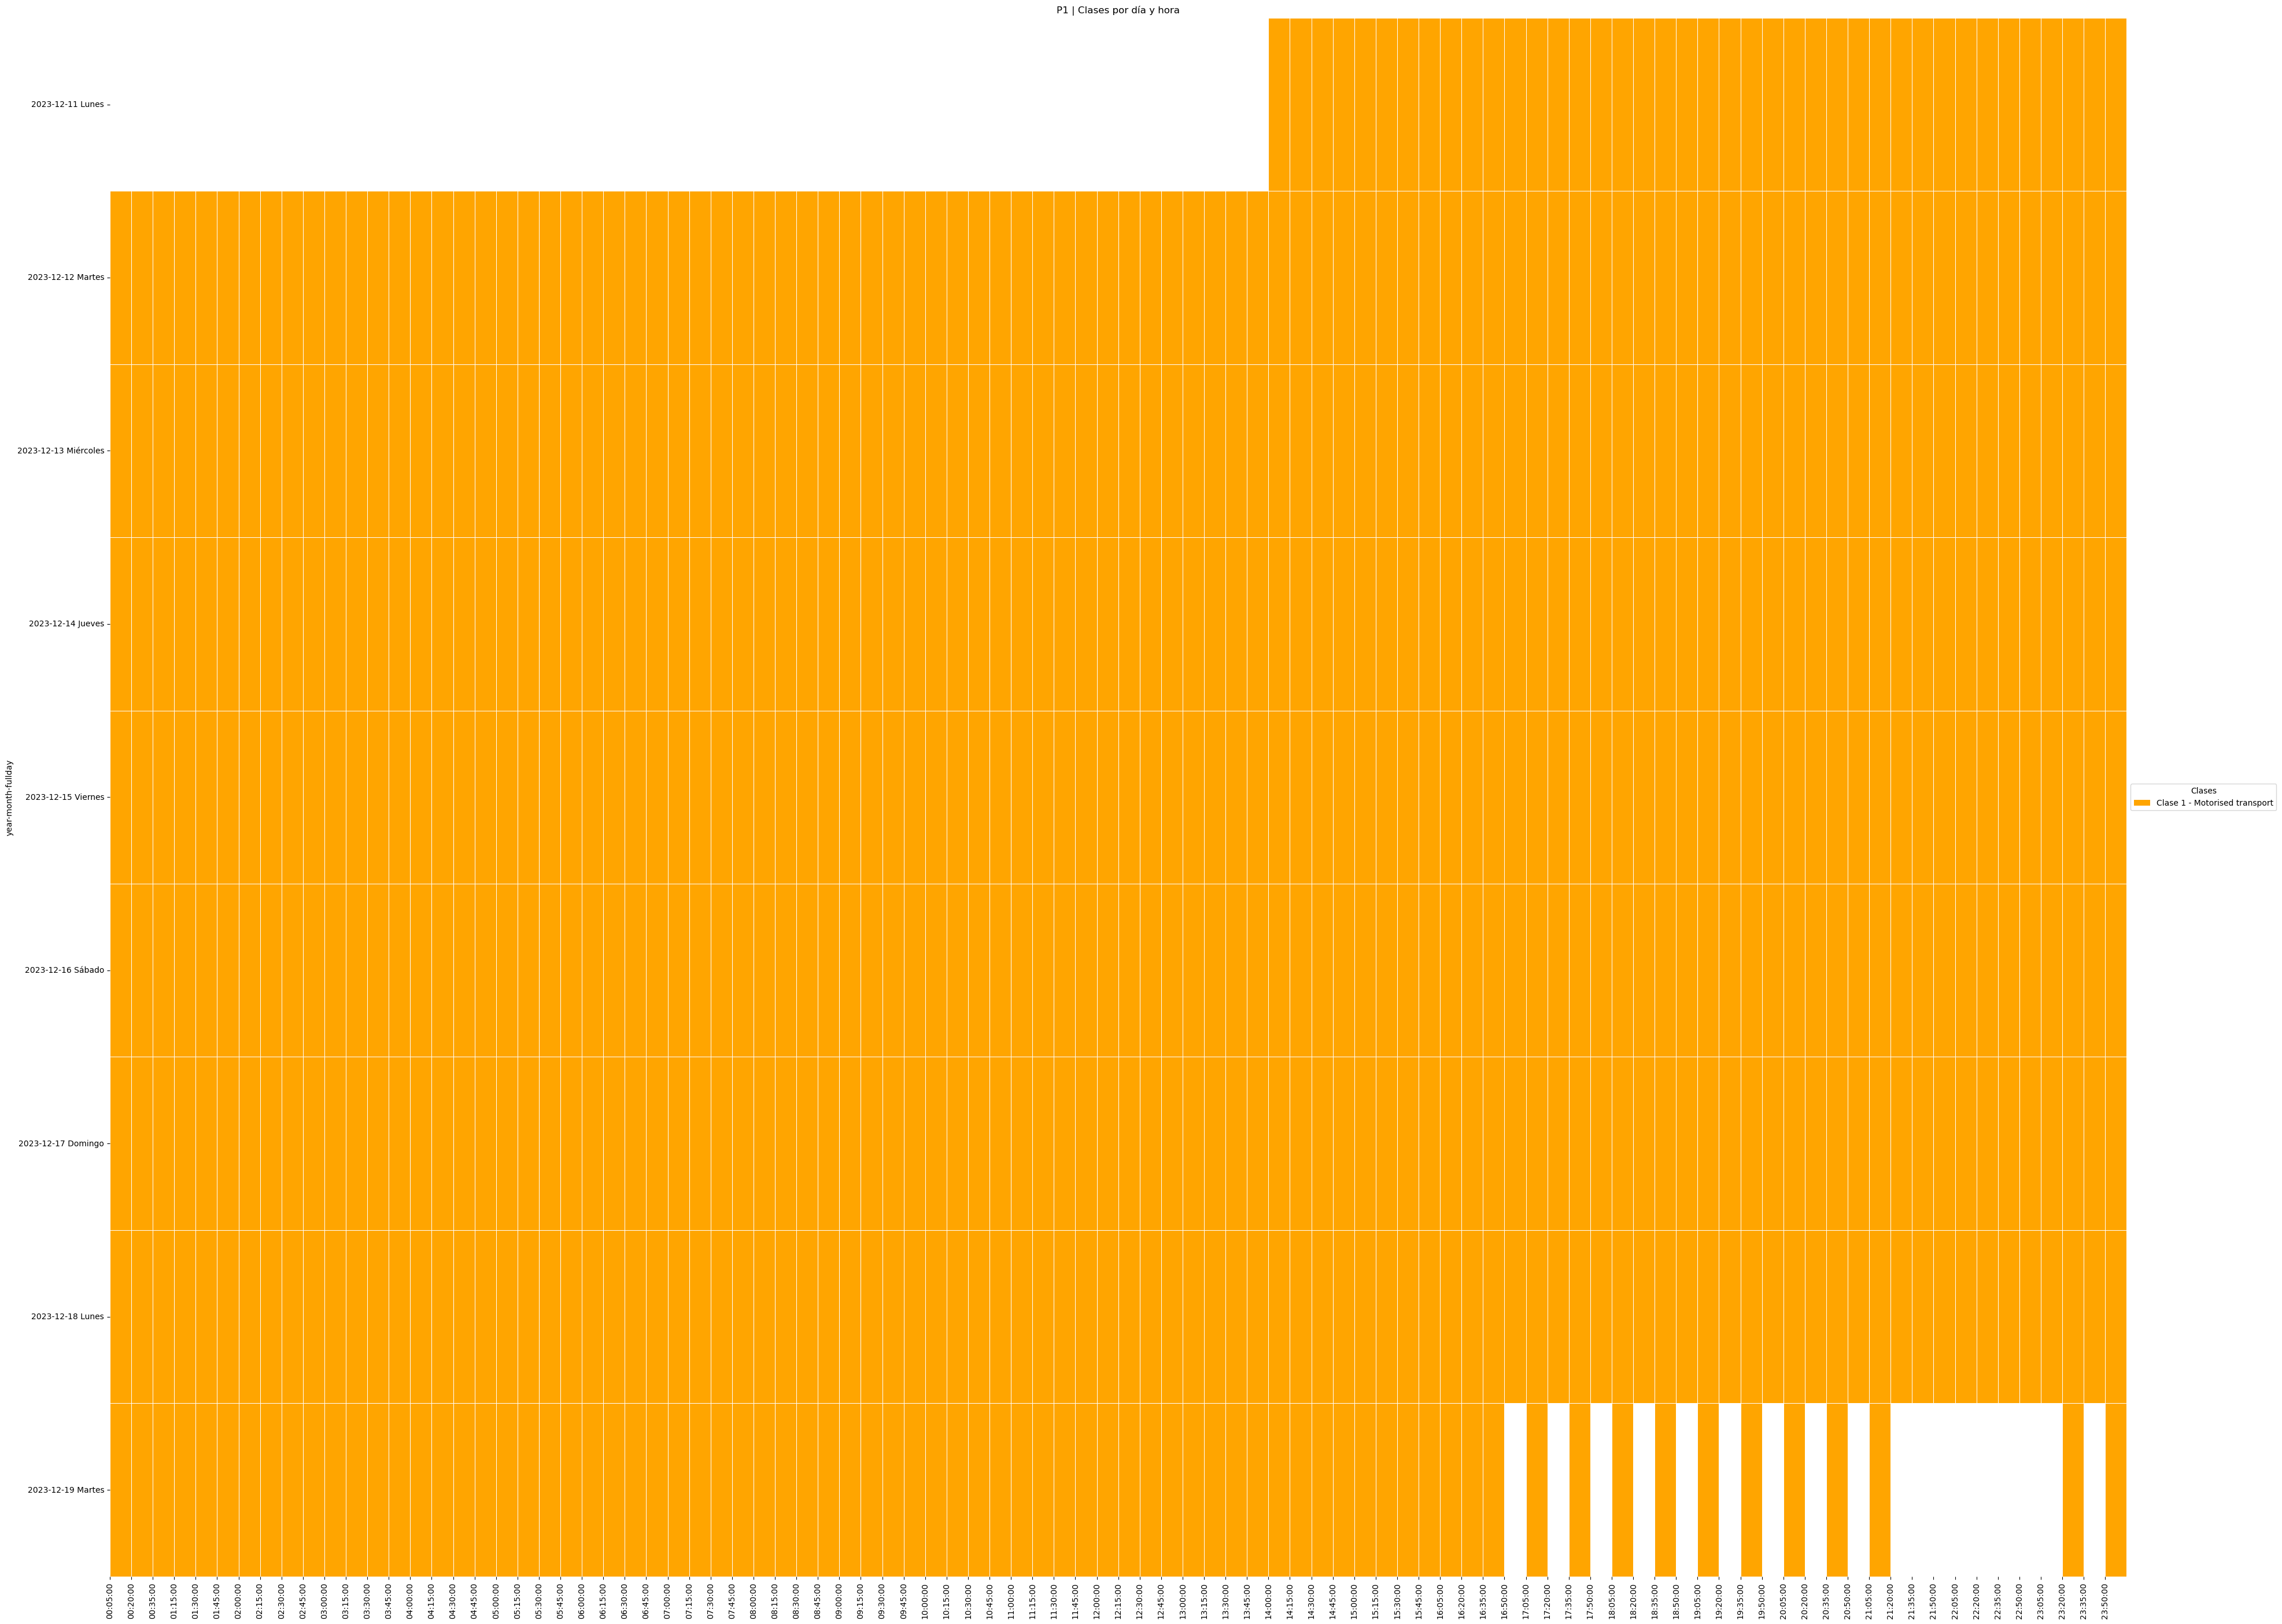

In [104]:
df_resampled = df_resampled.sort_values(by=["year", "month", "fullday"])

# map class to number
class_to_num = {class_name: index+1 for index, class_name in enumerate(df_resampled['single_class'].unique())}
df_resampled['class_num'] = df_resampled['single_class'].map(class_to_num)

# inverting the dictionary to get the name of the class for the legend
name_class = {v: k for k, v in class_to_num.items()}

# mapping from classes numbers to colors
num_to_color = {num: COLLOR_PALLET[class_name] for class_name, num in class_to_num.items()}
cmap = [num_to_color[cls_num] for cls_num in name_class.keys()]

# leggend elements colors
legend_elements = [Patch(facecolor=num_to_color[cls_num], label=f"Clase {cls_num} - {name_class.get(cls_num, '')}") for cls_num in name_class.keys()]

day_class = pd.pivot_table(data=df_resampled, columns=df_resampled.index.time, index=["year", "month", "fullday"], values="class_num", aggfunc='mean')

plt.figure(figsize=(45, 35))

if day_class.isna().all().all() or day_class.empty:
    print("No valid data. Skipping...")
    
else:
    ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False)
    
    ax.set_xticks(range(len(day_class.columns)))
    ax.set_xticklabels([t.strftime('%H:%M:%S') for t in day_class.columns], rotation=90)
    
    yticklabels = [f"{idx[0]}-{idx[1]}-{idx[2]}" for idx in day_class.index]
    ax.set_yticklabels(yticklabels, rotation=0)
    
    plt.legend(handles=legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"{title} | Clases por día y hora")
    plt.plot()

    plt.savefig(f"{visualization_dir}/{title}_predictions_map_{stable_version}.png", bbox_inches='tight')
    print(f"Saved image at {visualization_dir}/{title}_predictions_map_{stable_version}.png")

plt.show()

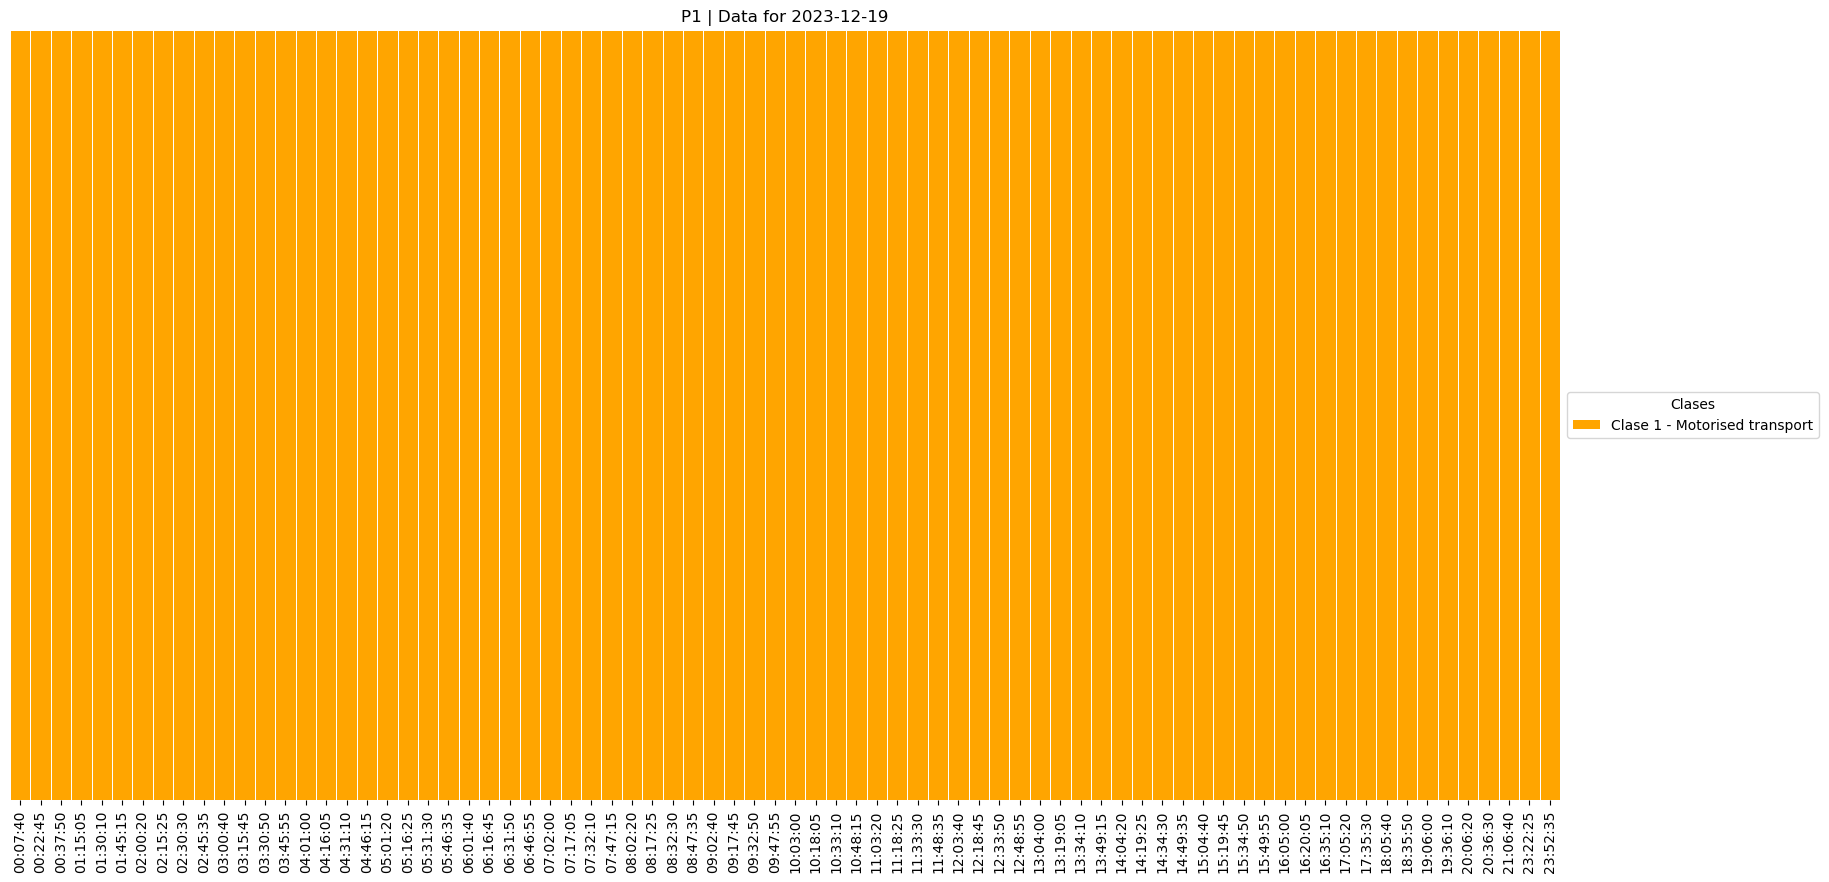

In [105]:
day = "19"

# filter for the specific day across all years and months
df_xth = df[df["fullday"].str.startswith(day)]

if df_xth.empty:
    print(f"No data for the {day}th day across all years and months. Skipping...")

else:
    plt.figure(figsize=(20, 10))
    
    # pivot is used to get the heatmap | aggfunc is used to get the mode of the classes for each time
    day_class = pd.pivot_table(data=df_xth, columns=df_xth.index.time, index=["year", "month"], values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
    
    if day_class.isna().all().all() or day_class.empty:
        print(f"No valid data for the {day}th day. Skipping...")

    else:
        # unique classes present in the pivot table
        unique_classes = set(day_class.dropna().values.flatten())

        # Filter legend elements for only those classes present
        current_legend_elements = [Patch(facecolor=cmap[int(cls_num)-1], label=f"Clase {cls_num} - {name_class[cls_num]}") for cls_num in unique_classes if cls_num in name_class]

        # setup the heatmap
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(name_class))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        
        # Hide the y-axis labels (to remove year and month labels)
        ax.yaxis.set_visible(False)
        
        # include the years and months in the dataset
        years = "-".join(map(str, sorted(df_xth["year"].unique())))
        months = "-".join(map(str, sorted(df_xth["month"].unique())))

        # legend
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {years}-{months}-{day}")

        plt.show()

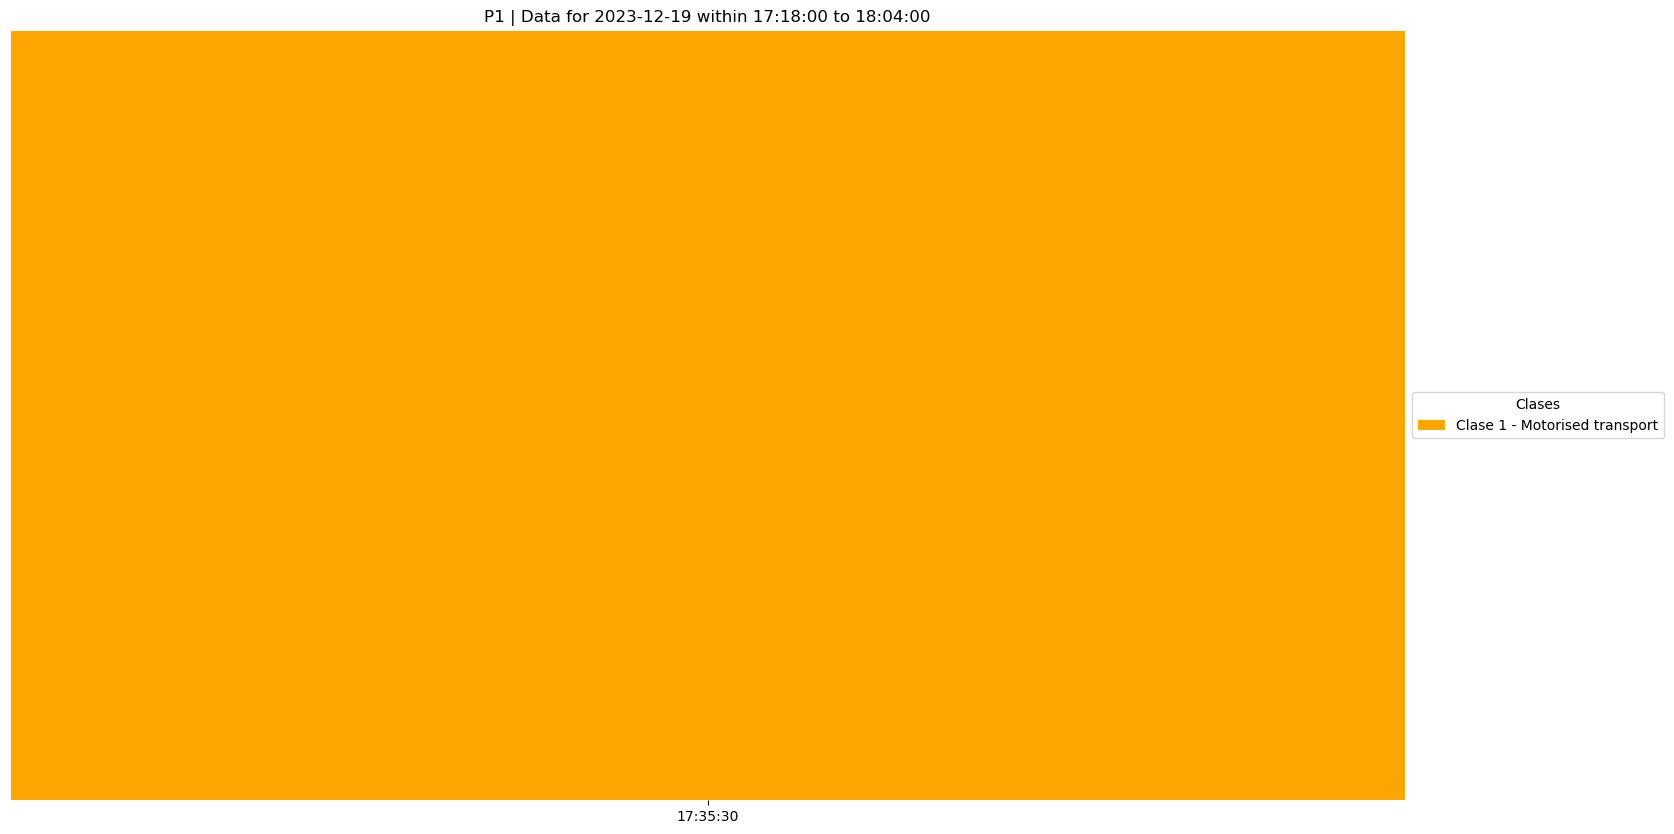

In [106]:
day = "19"

for year in sorted(df["year"].unique()):
    df_year = df[df["year"] == year]
    for month in sorted(df_year["month"].unique()):
        df_temp = df_year[df_year["month"] == month]
        
        df_xth = df_temp[df_temp["fullday"].str.startswith(day)]
        
        start_time = pd.to_datetime("17:18:00").time()
        end_time = pd.to_datetime("18:04:00").time()
        time_mask = (df_xth.index.time >= start_time) & (df_xth.index.time <= end_time)
        df_xth_filtered = df_xth[time_mask]
        
        if df_xth_filtered.empty:
            print(f"No data for the {day}th day in Year: {year}, Month: {month} within the specified time range. Skipping...")
            continue
        
        plt.figure(figsize=(18, 10))
        
        day_class = pd.pivot_table(data=df_xth_filtered, columns=df_xth_filtered.index.time, index="fullday", values="class_num", aggfunc=lambda x: x.mode()[0] if not x.empty else None)
        
        if day_class.isna().all().all() or day_class.empty:
            print(f"No valid data for Year: {year}, Month: {month}, Day: {day} within the specified time range. Skipping...")
            continue
        
        # Get unique classes present in the pivot table
        unique_classes = set(day_class.dropna().values.flatten())

        # Create a list of colors in the order of class numbers
        cmap = [num_to_color[int(cls_num)] for cls_num in unique_classes if cls_num in name_class]

        # Filter legend elements for only those classes present
        current_legend_elements = [Patch(facecolor=num_to_color[int(cls_num)], label=f"Clase {cls_num} - {name_class[cls_num]}") for cls_num in unique_classes if cls_num in name_class]

        # Create the heatmap
        ax = sns.heatmap(day_class, annot=False, cmap=cmap, linewidth=0.5, cbar=False, vmin=1, vmax=len(name_class))
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        
        # Completely hide the y-axis
        ax.yaxis.set_visible(False)
        
        plt.legend(handles=current_legend_elements, title="Clases", loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title(f"{title} | Data for {year}-{month}-{day} within {start_time.strftime('%H:%M:%S')} to {end_time.strftime('%H:%M:%S')}")

        plt.show()